# Part 5 - Spatial operations with the `arcgis_geometry` Library

The `arcgis_geometry` library, fully released in version 2.4.4 of the ArcGIS API for Python, is a platform-independent Python package for geometry representations and operations, powered by high-performance Rust core libraries. The arcgis geometry package delivers a unified, faster geometry API across the ArcGIS ecosystem. The goal is to accelerate analysis of complex geometries, improve memory safety and stability, strengthen cross-platform integration, and create a consistent developer experience supported by first-class documentation.

The `arcgis_geometry` library is now included as the premier geometry engine rather than relying on 3rd party libraries such as Shapely or PySHP and without needing an `arcpy` license. Working with geometries is ready to go out of the box.

Previously, in Part 3 of this guide, the ability to create geometry objects and execute spatial operations was introduced. The geometry constructors and method signatures largely remain the same with `arcgis_geometry`.

In [2]:
from arcgis.gis import GIS
from arcgis_geometry import Polygon, Geometry, Point, Polyline
from arcgis.geocoding import geocode

In [35]:
gis = GIS(profile='your_online_profile')

### Union

The first method, `<first geom object>.union(<second_geometry>)`, can be called off from a geometry object to construct the geometry that is the set-theoretic union of the input geometries. You are going to see an example of how to create a union of two polygons (e.g. geometry1 and geometry2):

In [3]:
geom1_json = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100}, 'rings': [[[-8232647.749922129, 4978983.410862541], [-8232389.7749516675, 4978840.091434507], [-8232762.405464557, 4978161.712808477], [-8233001.2711779475, 4978295.477607976], [-8232647.749922129, 4978983.410862541]]]}
geom2_json = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100}, 'rings': [[[-8232619.086036522, 4978994.876241834], [-8232275.11940924, 4979644.590982256], [-8231988.480553171, 4979482.162297151], [-8232380.220323131, 4978822.892928192], [-8232619.086036522, 4978994.876241834]]]}

In [4]:
geom1 = Polygon(geom1_json)

In [5]:
geom2 = Polygon(geom2_json)

In [16]:
print(type(geom1))
geom1

<class 'arcgis_geometry.Polygon'>


{"spatialReference": {"wkid":102100,"latestWkid":3857}, "rings": [[[-8232647.749922129, 4978983.410862541], [-8232389.7749516675, 4978840.091434507], [-8232762.405464557, 4978161.712808477], [-8233001.2711779475, 4978295.477607976], [-8232647.749922129, 4978983.410862541]]]}

In [7]:
print(type(geom2))
geom2

<class 'arcgis_geometry.Polygon'>


{"spatialReference": {"wkid":102100,"latestWkid":3857}, "rings": [[[-8232619.086036522, 4978994.876241834], [-8232275.11940924, 4979644.590982256], [-8231988.480553171, 4979482.162297151], [-8232380.220323131, 4978822.892928192], [-8232619.086036522, 4978994.876241834]]]}

In [8]:
geom_union = geom1.union(geom2)
geom_union

{"spatialReference": {"wkid":3857}, "rings": [[[-8232647.749922129, 4978983.410862541], [-8232452.526684041, 4978874.953508047], [-8232619.086036522, 4978994.876241834], [-8232275.11940924, 4979644.590982256], [-8231988.480553171, 4979482.162297151], [-8232380.220323131, 4978822.892928192], [-8232393.836798428, 4978832.696790406], [-8232762.405464557, 4978161.712808477], [-8233001.2711779475, 4978295.477607976]]]}

### Difference

The, `difference(second_geometry)`, constructs the geometry that is composed only of the region unique to the base geometry but not part of the second geometry. The following illustration shows the results that are inside the source geometry, but not the second geometry.

In [9]:
geom3_json = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100}, 'rings': [[[-8233020.380435019, 4978303.121194171], [-8232303.783294846, 4979640.769189159], [-8232026.699067313, 4979497.449761124], [-8232791.069350163, 4978112.028623458], [-8233020.380435019, 4978303.121194171]]]}

In [10]:
geom3 = Polygon(geom3_json)
geom3

{"spatialReference": {"wkid":102100,"latestWkid":3857}, "rings": [[[-8233020.380435019, 4978303.121194171], [-8232303.783294846, 4979640.769189159], [-8232026.699067313, 4979497.449761124], [-8232791.069350163, 4978112.028623458], [-8233020.380435019, 4978303.121194171]]]}

In [11]:
geom_diff = geom_union.difference(geom3)
geom_diff

{"spatialReference": {"wkid":3857}, "rings": [[[-8232762.405464557, 4978161.712808477], [-8232763.36188506, 4978162.248403958], [-8232479.220830846, 4978677.254064721]], [[-8232380.220323131, 4978822.892928192], [-8232393.566643669, 4978832.502278979], [-8232026.699067313, 4979497.449761124], [-8232282.869588468, 4979629.951754826], [-8232275.11940924, 4979644.590982256], [-8231988.480553171, 4979482.162297151]]]}

### Symmetric difference

Similar to `difference()`, the method `symmetric_difference(second_geometry)` constructs the geometry that is the union of two geometries minus the intersection of those geometries. As told by the definition, the result of `difference()` should always be included/contained in the result of a `symmetric_difference()`.

In [12]:
geom_sdiff = geom_union.symmetric_difference(geom3)
geom_sdiff

{"spatialReference": {"wkid":3857}, "rings": [[[-8233020.380435019, 4978303.121194171], [-8232303.783294846, 4979640.769189159], [-8232282.869588468, 4979629.951754826], [-8232619.086036522, 4978994.876241834], [-8232452.526684041, 4978874.953508047], [-8232647.749922129, 4978983.410862541], [-8233001.2711779475, 4978295.477607976], [-8232763.36188506, 4978162.248403958], [-8232791.069350163, 4978112.028623458]], [[-8232762.405464557, 4978161.712808477], [-8232763.36188506, 4978162.248403958], [-8232479.220830788, 4978677.254064826]], [[-8232479.220830788, 4978677.254064826], [-8232393.836798428, 4978832.696790406], [-8232393.566643669, 4978832.502278979]], [[-8232380.220323131, 4978822.892928192], [-8232393.566643669, 4978832.502278979], [-8232026.699067313, 4979497.449761124], [-8232282.869588468, 4979629.951754826], [-8232275.11940924, 4979644.590982256], [-8231988.480553171, 4979482.162297151]]]}

In [13]:
print(type(geom_sdiff))

<class 'arcgis_geometry.Polygon'>


### intersect() V.S. overlaps()

The `intersect()` method constructs a geometry that is the geometric intersection of the two input geometries. Different dimension values can be used to create different shape types. The intersection of two geometries of the same shape type is a geometry containing only the regions of overlap between the original geometries, and its arguments include:
  - `second_geometry`: required `arcgis.geometry.Geometry`. 
  - A second geometry `dimension`: required Integer. The topological dimension (shape type) of the resulting geometry, which can be:
    - 1: A zero-dimensional geometry (point or multipoint).
    - 2: A one-dimensional geometry (polyline).
    - 4: A two-dimensional geometry (polygon).

In [17]:
# scroll to the top of this notebook where these two geometries are visualized
geom_intersection = geom1.intersections(geom2)
geom_intersection

[{"spatialReference": {"wkid":3857}, "rings": [[[-8232393.836798428, 4978832.696790406], [-8232452.526684042, 4978874.953508048], [-8232389.7749516675, 4978840.091434507]]]}]

While `intersect()` returns a new geometry object, the `overlaps()` method will return a boolean value which indicates if the intersection of the two geometries has the same shape type as one of the input geometries and is not equivalent to either of the input geometries.

According to the definition, we can tell that `overlaps()` contains two operations - first, it creates the intersection of first and second geometries; second, it checks if the intersection is None, or equivalence to either the first or the second geometry - if so, then overlaps() returns `False`, or else, returns `True`.

In [18]:
# True, because the intersection of geom1 and geom2 is partial shape of geom1, and is not
# equivalent to either one
geom1.overlaps(geom2)

True

In [19]:
# False, because the intersection of geom1 and geom_intersection is geom_intersection, 
# and that is equivalent to the second geometry
geom1.overlaps(geom_intersection[0])

False

### Equals

`equals()` compares the source geometry with the second to check if they are of the same shape type and define the same set of points in the plane. This is a `2D comparison` only; M and Z values are ignored.

In [20]:
geom1.equals(geom1)

True

In [21]:
geom_intersection[0].equals(geom_sdiff)

False

### Generalize() V.S. buffer()

Next, you will see the difference between these two spatial operations:
  - `generalize(max_offset)` - Creates a new simplified geometry using a specified maximum offset tolerance (as shown in Figs 1 and 2). The result of the `generalize()` operation against a polyline object is a new polyline, while that against a polygon object is a new polygon.
  - `buffer(distance)` - Constructs a polygon at a specified distance from the geometry. The buffering process merges buffer polygons that overlap. Negative distances greater than one-half the maximum interior width of a polygon result in an empty geometry. Illustration of `buffer()` operations against different geomtry types can be found in Fig 3, which also shows that results of `buffer()` are always polygon objects.

<img src="https://desktop.arcgis.com/en/arcmap/10.3/tools/editing-toolbox/GUID-BA4E50F7-938B-4695-9E96-B9C3B7B96365-web.gif"  />
<p><center>Fig 1. Generialize operation against a polyline object (Source: <a href="https://desktop.arcgis.com/en/arcmap/10.3/tools/editing-toolbox/generalize.htm">ArcMap Toolbox Help</a>)</center></p>
  
<img src="https://desktop.arcgis.com/en/arcmap/latest/tools/cartography-toolbox/GUID-128637E4-C21F-436E-9D37-62741C3B9E93-web.png"  />
<p><center>Fig 2. Generialize operation against a polygon object (Source: <a href="https://desktop.arcgis.com/en/arcmap/latest/tools/cartography-toolbox/simplify-polygon.htm">ArcMap Toolset Help</a>)</center><p>
  
<img src="http://webhelp.esri.com/arcgisdesktop/9.2/published_images/ST_Buffer.gif" />
<p><center>Fig 3. Buffer operation (Source: <a href="http://webhelp.esri.com/arcgisdesktop/9.2/index.cfm?TopicName=Spatial_operations">ArcGIS Desktop Help</a>)</center></p>

In [23]:
polyline1 = Polyline({'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'paths': [[[-8235190.176786223, 4978434.716352775], [-8235198.537086192, 4978449.048295577],[-8235190.176786223, 4978458.602924112],[-8235172.261857721, 4978455.019938411],[-8235166.290214886, 4978452.631281278], [-8235154.346929218, 4978452.631281278],[-8235145.9866292495, 4978456.214266978],[-8235145.9866292495, 4978465.768895513], [-8235145.9866292495, 4978471.7405383475],[-8235145.9866292495, 4978480.100838316],[-8235148.375286384, 4978484.878152583], [-8235150.763943518, 4978487.266809717],[-8235160.318572052, 4978488.461138284],[-8235165.09588632, 4978489.65546685], [-8235171.067529154, 4978492.044123984],[-8235178.233500555, 4978492.044123984],[-8235181.816486255, 4978490.849795417], [-8235185.399471956, 4978487.266809717],[-8235197.342757625, 4978478.906509749],[-8235206.89738616, 4978480.100838316],[-8235210.48037186, 4978495.627109685], [-8235210.48037186, 4978508.76472392], [-8235210.48037186, 4978509.959052487], [-8235210.48037186, 4978514.736366754], [-8235210.48037186, 4978520.7080095885], [-8235210.48037186, 4978521.902338156], [-8235210.48037186, 4978523.096666723], [-8235210.48037186, 4978524.29099529], [-8235210.48037186, 4978525.485323856], [-8235210.48037186, 4978529.068309557], [-8235206.89738616, 4978535.039952391], [-8235206.89738616, 4978536.234280958], [-8235205.703057593, 4978542.205923792], [-8235204.508729026, 4978543.400252359], [-8235203.314400459, 4978544.594580926], [-8235202.120071892, 4978545.788909492], [-8235196.148429058, 4978550.56622376], [-8235196.148429058, 4978552.954880893], [-8235196.148429058, 4978554.14920946], [-8235196.148429058, 4978555.343538027], [-8235196.148429058, 4978556.537866594], [-8235194.954100491, 4978557.732195161], [-8235194.954100491, 4978558.926523728], [-8235194.954100491, 4978560.120852294], [-8235193.759771924, 4978561.315180861], [-8235190.176786223, 4978569.67548083], [-8235165.09588632, 4978581.618766498], [-8235165.09588632, 4978592.3677236], [-8235161.512900619, 4978594.756380733], [-8235161.512900619, 4978595.9507093], [-8235156.735586352, 4978599.533695001], [-8235151.958272084, 4978600.728023568], [-8235150.763943518, 4978600.728023568], [-8235147.180957817, 4978603.116680701], [-8235135.237672148, 4978607.893994969], [-8235134.043343581, 4978607.893994969], [-8235132.849015014, 4978607.893994969], [-8235132.849015014, 4978609.088323535], [-8235131.654686447, 4978609.088323535], [-8235130.46035788, 4978609.088323535], [-8235130.46035788, 4978610.282652102], [-8235125.683043613, 4978611.476980669], [-8235105.379457977, 4978611.476980669], [-8235101.796472277, 4978611.476980669], [-8235100.60214371, 4978611.476980669], [-8235099.407815143, 4978611.476980669], [-8235098.2134865755, 4978611.476980669], [-8235097.0191580085, 4978611.476980669], [-8235095.8248294415, 4978611.476980669], [-8235087.464529474, 4978611.476980669], [-8235086.270200907, 4978611.476980669], [-8235085.07587234, 4978611.476980669], [-8235083.881543773, 4978611.476980669], [-8235082.687215206, 4978611.476980669], [-8235081.492886639, 4978611.476980669], [-8235075.521243805, 4978611.476980669], [-8235074.326915238, 4978611.476980669], [-8235063.577958137, 4978607.893994969], [-8235059.994972437, 4978605.505337835], [-8235051.6346724685, 4978591.173395033], [-8235051.6346724685, 4978589.979066466], [-8235050.4403439015, 4978587.590409333], [-8235034.914072532, 4978579.230109365], [-8235027.748101131, 4978558.926523728], [-8235026.553772564, 4978558.926523728], [-8235026.553772564, 4978555.343538027], [-8235028.942429698, 4978555.343538027], [-8235031.331086832, 4978555.343538027], [-8235045.663029634, 4978555.343538027], [-8235051.6346724685, 4978555.343538027], [-8235052.829001036, 4978544.594580926], [-8235052.829001036, 4978543.400252359], [-8235052.829001036, 4978531.45696669], [-8235052.829001036, 4978530.262638124], [-8235052.829001036, 4978526.679652423], [-8235052.829001036, 4978520.7080095885], [-8235049.2460153345, 4978520.7080095885], [-8235033.719743965, 4978520.7080095885], [-8235021.776458297, 4978520.7080095885], [-8235021.776458297, 4978521.902338156], [-8235021.776458297, 4978531.45696669], [-8235016.99914403, 4978537.428609525], [-8235012.221829762, 4978537.428609525], [-8235006.250186928, 4978537.428609525], [-8234994.306901259, 4978530.262638124], [-8234993.112572692, 4978529.068309557], [-8234991.918244125, 4978527.87398099], [-8234991.918244125, 4978526.679652423], [-8234989.529586992, 4978523.096666723], [-8234981.169287024, 4978514.736366754], [-8234981.169287024, 4978513.542038187], [-8234972.808987056, 4978499.210095385], [-8234979.974958457, 4978503.987409652], [-8234962.060029954, 4978489.65546685], [-8234960.865701388, 4978475.323524048], [-8234958.477044254, 4978470.5462097805], [-8234958.477044254, 4978465.768895513], [-8234958.477044254, 4978464.574566946], [-8234958.477044254, 4978463.380238379], [-8234958.477044254, 4978462.185909812], [-8234958.477044254, 4978452.631281278], [-8234958.477044254, 4978437.105009909], [-8234958.477044254, 4978435.910681342], [-8234964.448687088, 4978421.5787385395], [-8234965.643015655, 4978421.5787385395], [-8234977.586301323, 4978408.441124304], [-8234985.946601291, 4978402.46948147], [-8234988.335258425, 4978401.275152903], [-8234988.335258425, 4978400.080824336], [-8234989.529586992, 4978400.080824336], [-8234989.529586992, 4978398.886495769], [-8234996.695558393, 4978394.109181502], [-8234997.889886959, 4978394.109181502], [-8234999.0842155265, 4978394.109181502], [-8235001.4728726605, 4978390.526195802], [-8235008.638844062, 4978382.165895834], [-8235009.833172629, 4978382.165895834], [-8235024.165115431, 4978371.416938731], [-8235036.108401099, 4978367.833953031], [-8235038.497058233, 4978367.833953031], [-8235040.885715366, 4978367.833953031], [-8235054.023329602, 4978364.25096733], [-8235055.217658169, 4978355.890667362], [-8235055.217658169, 4978353.502010229], [-8235055.217658169, 4978352.307681662], [-8235055.217658169, 4978351.113353095], [-8235052.829001036, 4978343.947381694], [-8235040.885715366, 4978320.060810357], [-8235033.719743965, 4978318.86648179], [-8235027.748101131, 4978316.477824656], [-8235018.193472596, 4978312.894838956], [-8235016.99914403, 4978311.700510389], [-8234999.0842155265, 4978311.700510389], [-8234964.448687088, 4978323.643796057], [-8234960.865701388, 4978328.421110325], [-8234960.865701388, 4978329.615438892], [-8234956.08838712, 4978337.97573886], [-8234954.894058553, 4978339.170067427], [-8234954.894058553, 4978340.364395994], [-8234953.6997299865, 4978341.55872456], [-8234953.6997299865, 4978342.753053127], [-8234953.6997299865, 4978343.947381694], [-8234950.116744285, 4978348.724695961], [-8234944.145101451, 4978355.890667362], [-8234942.950772884, 4978355.890667362], [-8234942.950772884, 4978357.084995929], [-8234941.756444317, 4978358.279324496], [-8234941.756444317, 4978359.473653063], [-8234940.56211575, 4978360.66798163], [-8234922.647187248, 4978378.582910133]]]})
type(polyline1)

arcgis_geometry.Polyline

In [26]:
from IPython.display import display_svg, clear_output, display, HTML
import time

In the cell below, we loop through various offset distances and observe how that effects the amount of generalization. The higher the offset, the greater the generalization. The greater the generalization, the fewer the vertices, leading to less complexity in the resulting geometry. Compact geometries take up less space (for storage) and memory as well.

In [29]:
time.sleep(2)
for offset in [1,10,15,20,25,30,35,40,45,50]:
    # apply generalization
    generalized_polyline = polyline1.generalize(max_offset=offset)
    
    # display logic to create an animation
    display_svg(generalized_polyline)
    time.sleep(1)
    clear_output()

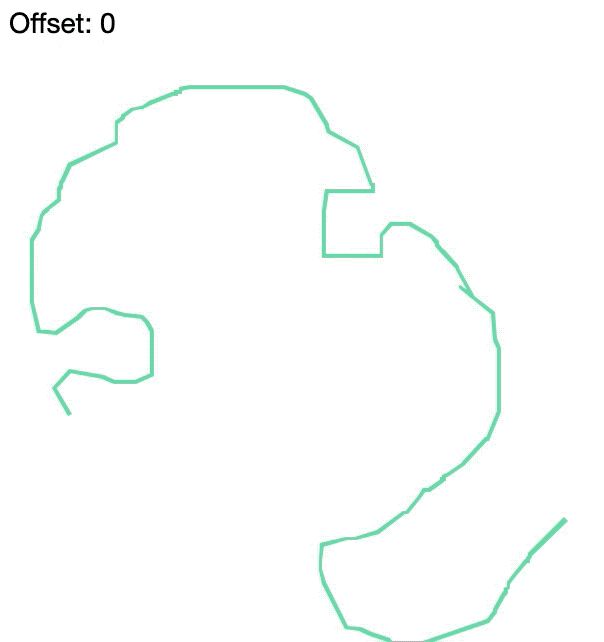

**Buffer**

In the cell below, we loop through various distance measures for the buffer tool. We start with a distance of `1m` (the unit is meters as that is the units of the geometry's spatial reference), where the buffer result is quite similar to the source geometry. As the distance increases, the effect of buffering increases, producing thicker polygons. The tool generalizes the resulting buffer polygon to produce a smooth shape and dissolves overlaps. At a distance of `70m`, the buffer looks like a simple circle.

In [31]:
time.sleep(2)
for distance in [1,10,15,20,25,30,35,40,45,50,55,60,65,70]:
    # apply buffer
    buffered_polyline = polyline1.buffer(distance=distance)
    
    # display logic to create an animation
    display_svg(buffered_polyline)
    time.sleep(1)
    clear_output()

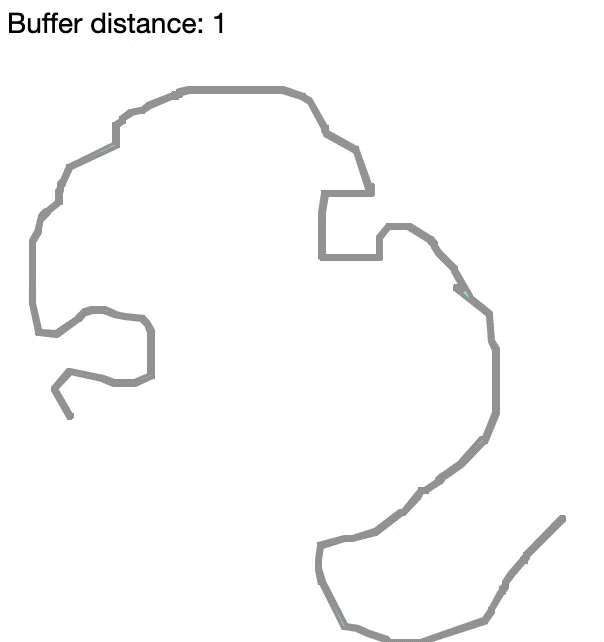

### Find the nearest point

Imagine that you are jogging on a trail (drawn as the light blue line segment on the map) inside Central Park and looking for a water fountain. You know the water fountain is located inside the pavilion (as marked as the blue pin). You want to know: What is the shortest path from the trail to pavilion?

The method `query_point_and_distance(second_geometry, use_percentage=False)` can find the point on a polyline nearest to the `second_geometry` and the distance between these points. It also returns information about which side of the line the `second_geometry` is on as well as the distance along the line where the nearest point occurs.

In [32]:
access_point = Point({'spatialReference': {'latestWkid': 3857, 'wkid': 102100}, 
                      'x': -8234818.501757936, 'y': 4978337.398475052})

In [33]:
access_polyline = Polyline({'spatialReference': {'latestWkid': 3857, 'wkid': 102100}, 
                            'paths': [[[-8234920.019686119, 4978251.645698531], [-8234885.38415768, 4978242.091069995], 
                                       [-8234849.554300674, 4978245.674055696], [-8234808.947129401, 4978255.228684231],
                                       [-8234773.117272396, 4978251.645698531], [-8234751.619358192, 4978239.702412861],
                                       [-8234736.093086823, 4978215.815841525]]]})

In [40]:
a_p = Point({"x":-8234808.9471294014,"y":4978255.2286842307,"spatialReference":{"wkid":102100,"latestWkid":3857}})

### Contains

The method `contains(second_geometry, relation=None)` indicates if the base geometry contains the comparison geometry.

In [41]:
access_polyline.contains(a_p)

True

### Clip a geometry object

The method `clip(envelope)` constructs the intersection of the geometry and the specified extent. Note that, if `ArcPy` is not installed, none is returned. The one and required input parameter is:
  - `envelope`: required tuple. The tuple must be in the form of a tuple (XMin, YMin, XMax, YMax) where each value represents the lower left bound and upper right bound of the extent.

In [43]:
access_polygon = Polygon({'spatialReference': {'latestWkid': 3857, 'wkid': 102100}, 
                          'rings': [[[-8234920.019686119, 4978251.645698531], [-8234885.38415768, 4978242.091069995], 
                                     [-8234849.554300674, 4978245.674055696], [-8234808.947129401, 4978255.228684231],
                                     [-8234773.117272396, 4978251.645698531], [-8234751.619358192, 4978239.702412861],
                                     [-8234736.093086823, 4978215.815841525], [-8234663.657066563, 4978349.222320599], 
                                     [-8234737.705437716, 4978225.012149632], [-8234935.963979837, 4978263.2306637755]]]})
access_polygon

{"spatialReference": {"wkid":102100,"latestWkid":3857}, "rings": [[[-8234920.019686119, 4978251.645698531], [-8234885.38415768, 4978242.091069995], [-8234849.554300674, 4978245.674055696], [-8234808.947129401, 4978255.228684231], [-8234773.117272396, 4978251.645698531], [-8234751.619358192, 4978239.702412861], [-8234736.093086823, 4978215.815841525], [-8234663.657066563, 4978349.222320599], [-8234737.705437716, 4978225.012149632], [-8234935.963979837, 4978263.2306637755]]]}

In [45]:
clipped = access_polygon.clip(access_polyline.envelope)
clipped

{"spatialReference": {"wkid":3857}, "rings": [[[-8234920.019686119, 4978251.645698531], [-8234885.38415768, 4978242.091069995], [-8234849.554300674, 4978245.674055696], [-8234808.947129401, 4978255.228684231], [-8234773.117272396, 4978251.645698531], [-8234751.619358192, 4978239.702412861], [-8234736.093086823, 4978215.815841525], [-8234736.093086823, 4978227.716738227], [-8234737.705437716, 4978225.012149632], [-8234894.453710948, 4978255.228684231], [-8234920.019686119, 4978255.228684231]]]}

Up till this point, you have tried creating geometry objects and performed spatial operations such as `union` and `intersect`, from the built-in methods of the `arcgis_geometry` package. Doing so executed the operations using the Rust powered default geometry engine included with version 2.4.4. 